В качестве датасета будем использовать набор данных с характеристиками, которые могут быть связаны с сахарным диабетом:

Признак диабета,
Высокое Артериальное Давление,
Высокий уровень холестерина,
Проверка уровня холестерина,
Курильщик,
Инсульт,
Сердечные заболевания или приступ,
Физическая активность,
Фрукты,
Овощи,
Потребление алкоголя,
Наличие мед страховки,
Ментальное здоровье,
Физическая форма,
Пол,
Возраст,
Образование,
Доход

In [ ]:
import pandas as pd
from sklearn.decomposition import FactorAnalysis
from statsmodels.multivariate.factor import Factor
df = pd.read_csv('diabetes.csv')
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Взглянем на размер датафрейма

In [ ]:
df.shape


(253680, 22)

Наблюдений у нас очень много. Из-за этого обработка данных может быть долгой. Факторный анализ требует множества вычислений, поэтому работа с полными данными может быть довольно медленной. Решение простое — сделать случайную выборку из данных: например, взять всего 1000 наблюдений. А потом провести расчеты на полной версии данных.

In [ ]:
df_sample = df.sample(1000)


Исключим одну независимую переменную Diabetes_012

In [ ]:
df_sample = df_sample[['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income']]

In [ ]:
print(df_sample.describe())


            HighBP     HighChol    CholCheck          BMI       Smoker  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.426000     0.437000     0.963000    28.096000     0.449000   
std       0.494741     0.496263     0.188856     6.617293     0.497641   
min       0.000000     0.000000     0.000000    16.000000     0.000000   
25%       0.000000     0.000000     1.000000    24.000000     0.000000   
50%       0.000000     0.000000     1.000000    27.000000     0.000000   
75%       1.000000     1.000000     1.000000    31.000000     1.000000   
max       1.000000     1.000000     1.000000    92.000000     1.000000   

            Stroke  HeartDiseaseorAttack  PhysActivity       Fruits  \
count  1000.000000             1000.0000   1000.000000  1000.000000   
mean      0.052000                0.1020      0.777000     0.614000   
std       0.222138                0.3028      0.416467     0.487074   
min       0.000000                0.0000      0.0

Обратим внимание, что у разных переменных разные шкалы. Нужно привести переменные к стандартизированным значениям.

In [ ]:
for col in df.columns:
    df[col] = (df[col] - df[col].mean()) / df[col].std()


Начнём с того, что вычислим связь между переменными и факторами для случайного числа факторов. Допустим, возьмем три.

Для этого используем загруженный метод Factor. В качестве аргументов мы указываем наш датафрейм, желаемое число факторов и метод, который мы будем использовать. В данном случае pa соответствует методу главных компонент.

Само преобразование делается в два шага. Сначала создаём модель с желаемыми параметрами и сохраняем её как переменную, а затем используем метод fit() и вычисляем результат преобразований.

In [ ]:
fa = Factor(df, n_factor=4, method='pa')
res = fa.fit()

In [ ]:
fac = FactorAnalysis(n_components=2)
resu = fac.fit(df)
pd.DataFrame(fac.components_, columns = df.columns)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.169703,0.115179,0.059827,0.007146,6.495544,0.012186,0.006386,0.020323,-0.070702,-0.045554,...,-0.004557,0.018909,0.294043,0.761102,1.314819,0.084639,0.020750,-0.068208,-0.120686,-0.257817
1,0.222660,0.168852,0.130133,0.009790,-0.293383,0.116862,0.052302,0.100389,-0.141770,-0.051352,...,-0.011441,0.055744,0.748909,2.654033,5.334655,0.220139,-0.027152,0.897872,-0.370445,-1.047599


Давайте теперь поймем, что именно мы получили. Начнем с того, что посмотрим на таблицу факторных нагрузок. Она отражает корреляцию между фактором и переменной. Подсветим все значения больше 0.3 и меньше -0.3.

In [ ]:
res.get_loadings_frame(threshold=0.3)


,factor 0,factor 1,factor 2,factor 3
GenHlth,-0.735658,0.060090,-0.140921,-0.083876
DiffWalk,-0.615682,0.008891,-0.195822,0.043372
PhysHlth,-0.608425,0.136664,-0.385874,-0.003801
Income,0.578737,-0.272872,-0.292657,-0.337446
HighBP,-0.444002,-0.354978,0.095572,-0.074813
Education,0.427344,-0.170735,-0.348006,-0.128378
Diabetes_012,-0.398598,-0.186070,0.026937,-0.098581
PhysActivity,0.366678,-0.079225,-0.066359,0.094203
MentHlth,-0.351565,0.278035,-0.226389,-0.032720
HeartDiseaseorAttack,-0.350324,-0.205053,-0.003855,-0.011448


Видим в таблице какой-то первоначальный вариант группировки. Выделенные вместе переменные относятся к одному фактору, указанному в столбце. Можем попробовать интерпретировать их. Проще всего начать с третьего, который соответствует вопросам о наличии в рационе овощей и фруктов. Мы могли бы объединить его и сказать, что это скрытый фактор — «Питание».

Это очень слабый фактор (все значения не укладываются в диапазон -0.3—0.3). Кроме того, он связан с полом, образованием и физическим здоровьем: интуитивно кажется, что все эти вопросы связаны с питанием.

Со вторым сложнее. Там есть вопросы о возрасте, уровне холестерина и два вопроса о доступности медицинской помощи. Можем предположить, что это возрастные изменения: холестерин повышается с возрастом, доступность медицинской помощи становится более важной с течением возраста. Давайте предположим, что этот фактор можно объединить и связать с «возрастными изменениями».

Наконец, первый фактор состоит из наибольшего числа переменных. Большая часть из них связана с разными формами здоровья, дохода и уровня образования. Все вместе это можно объединить и назвать «Уровень жизни».

Итого, у нас получилось три фактора: уровень жизни, возрастные изменения и питание.

Метод локтя — это график, который мы оцениваем визуально.

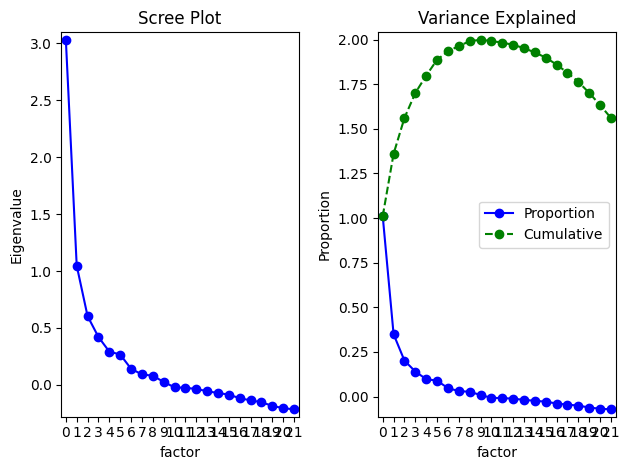

In [ ]:
import matplotlib.pyplot as plt
res.plot_scree()
plt.show()

Давайте попробуем оценить более строгий вариант с двумя факторами.

Видим, что фактически, сохраняются два первых фактора, которые мы назвали «уровень жизни» и «возрастные изменения».

В итоге можем сделать следующий вывод: факторы, потенциально связанные с сахарным диабетом могут быть объединены в две группы. Одни касаются уровня жизни, другие возрастных изменений.

In [ ]:
fa = Factor(df, n_factor=2, method='pa')
res = fa.fit()
res.get_loadings_frame(threshold=0.3)

,factor 0,factor 1
GenHlth,-0.748984,0.077764
DiffWalk,-0.610589,-0.001849
PhysHlth,-0.574538,0.107004
Income,0.522012,-0.263976
HighBP,-0.452921,-0.350007
Diabetes_012,-0.410984,-0.169963
Education,0.402801,-0.216955
PhysActivity,0.376805,-0.068544
MentHlth,-0.353824,0.259360
HeartDiseaseorAttack,-0.335860,-0.209061
